In [1]:
# imports
import pandas as pd
import seaborn as sns
import re
import numpy as np
import matplotlib.pyplot as plt
import glob
from Bio import SeqIO

In [2]:
residual_phages_checkv = pd.read_csv('../data/MAGs/viral_contigs/quality_summary.tsv', sep = '\t')
residual_phages_checkv['component'] = ['_'.join(re.split('_', v)[:3]) for v in  residual_phages_checkv['contig_id']]
residual_phages_checkv = residual_phages_checkv[~residual_phages_checkv['component'].str.contains('provirus')] # remove the prophages 
residual_phages_checkv_quality_filter = residual_phages_checkv[residual_phages_checkv['checkv_quality'].isin(['High-quality', 'Complete', 'Medium-quality'])]
quality_filter_phages = residual_phages_checkv_quality_filter['contig_id'].to_list()



In [3]:
# using checkv get these phages that are predicted with high completeness 
residual_phages_checkv_quality_filter 

,contig_id,contig_length,provirus,proviral_length,gene_count,viral_genes,host_genes,checkv_quality,miuvig_quality,completeness,completeness_method,contamination,kmer_freq,warnings,component
24,S1Ck141_39918,20405,No,NaN,27,23,0,Medium-quality,Genome-fragment,50.12,AAI-based (high-confidence),0.0,1.0,NaN,S1Ck141_39918
38,S1Ck141_40354,28948,No,NaN,49,33,0,Medium-quality,Genome-fragment,63.59,AAI-based (high-confidence),0.0,1.0,NaN,S1Ck141_40354
48,S1Ck141_234767,37533,No,NaN,44,20,0,Medium-quality,Genome-fragment,57.25,AAI-based (high-confidence),0.0,1.0,NaN,S1Ck141_234767
50,S1Ck141_1791,26039,No,NaN,48,31,0,Medium-quality,Genome-fragment,60.73,AAI-based (high-confidence),0.0,1.0,NaN,S1Ck141_1791
54,S1Ck141_157171,32289,No,NaN,37,20,2,High-quality,High-quality,100.00,AAI-based (high-confidence),0.0,1.0,NaN,S1Ck141_157171
136,S1Ck141_44171,20237,No,NaN,27,20,0,Medium-quality,Genome-fragment,62.64,AAI-based (high-confidence),0.0,1.0,NaN,S1Ck141_44171
141,S1Ck141_219588,21029,No,NaN,22,19,1,Medium-quality,Genome-fragment,52.34,AAI-based (high-confidence),0.0,1.0,NaN,S1Ck141_219588
175,S1Ck141_142512,18113,No,NaN,26,24,0,Medium-quality,Genome-fragment,55.57,AAI-based (high-confidence),0.0,1.0,NaN,S1Ck141_142512
227,S1Ck141_281750,25916,No,NaN,30,26,0,Medium-quality,Genome-fragment,64.40,AAI-based (high-confidence),0.0,1.0,NaN,S1Ck141_281750
241,S1Ck141_145228,26262,No,NaN,37,29,0,Medium-quality,Genome-fragment,55.60,AAI-based (high-confidence),0.0,1.0,NaN,S1Ck141_145228


In [4]:
residual_iphop = pd.read_csv('../data/MAGs/viral_contigs/Host_prediction_to_genus_m90.tsv', sep = '\t')

In [5]:
residual_iphop[residual_iphop['Virus'].isin(quality_filter_phages)]

,Virus,AAI to closest RaFAH reference,Host genus,Confidence score,List of methods
0,S1Ck141_145228,41.00,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,92.5,blast;94.60 iPHoP-RF;64.30 CRISPR;55.10
1,S1Ck141_157171,73.07,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,93.5,iPHoP-RF;89.20 RaFAH;78.80 CRISPR;67.80
3,S1Ck141_1791,26.71,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,97.8,blast;91.60 RaFAH;90.20 iPHoP-RF;51.20
4,S1Ck141_1791,26.71,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,91.5,blast;93.80 iPHoP-RF;77.30
6,S1Ck141_213095,74.76,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,98.8,blast;95.80 RaFAH;89.30 iPHoP-RF;64.00
7,S1Ck141_213095,74.76,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,95.4,blast;96.80 iPHoP-RF;61.40
8,S1Ck141_213095,74.76,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,94.3,blast;96.00 iPHoP-RF;75.20
9,S1Ck141_213095,74.76,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,91.6,blast;93.90
10,S1Ck141_219588,68.59,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,92.0,RaFAH;92.40 iPHoP-RF;61.90
11,S1Ck141_219588,68.59,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,90.8,blast;93.20


In [6]:
for i in range(len(residual_iphop[residual_iphop['Virus'].isin(quality_filter_phages)])): 
    print(residual_iphop[residual_iphop['Virus'].isin(quality_filter_phages)].iloc[i]['Virus'])
    print(residual_iphop[residual_iphop['Virus'].isin(quality_filter_phages)].iloc[i]['Host genus'])
    print()
    
host_dict = dict(zip(residual_iphop['Virus'], residual_iphop['Host genus']))


S1Ck141_145228
d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Hafnia

S1Ck141_157171
d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Escherichia

S1Ck141_1791
d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Escherichia

S1Ck141_1791
d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Citrobacter

S1Ck141_213095
d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Escherichia

S1Ck141_213095
d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Klebsiella

S1Ck141_213095
d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Citrobacter

S1Ck141_213095
d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;g__Scandinavium

S

In [7]:
residual_iphop['Name'] =  residual_iphop['Virus'] + '; ' + [re.split('g__',h)[-1] for h in residual_iphop['Host genus']]
name_dict = dict(zip(residual_iphop['Virus'], residual_iphop['Name']))
name_dict

{'S1Ck141_145228': 'S1Ck141_145228; Hafnia',
 'S1Ck141_157171': 'S1Ck141_157171; Escherichia',
 'S1Ck141_177389|provirus_12762_35169': 'S1Ck141_177389|provirus_12762_35169; RHBSTW-00994',
 'S1Ck141_1791': 'S1Ck141_1791; Citrobacter',
 'S1Ck141_205193|provirus_14363_40513': 'S1Ck141_205193|provirus_14363_40513; Lactococcus_A',
 'S1Ck141_213095': 'S1Ck141_213095; Scandinavium',
 'S1Ck141_219588': 'S1Ck141_219588; Pseudescherichia',
 'S1Ck141_281750': 'S1Ck141_281750; Citrobacter_D',
 'S1Ck141_291019': 'S1Ck141_291019; Enterobacter',
 'S1Ck141_306377|provirus_39309_62871': 'S1Ck141_306377|provirus_39309_62871; Escherichia',
 'S1Ck141_35118': 'S1Ck141_35118; Citrobacter_A',
 'S1Ck141_39918': 'S1Ck141_39918; Escherichia',
 'S1Ck141_40354': 'S1Ck141_40354; Citrobacter',
 'S1Ck141_4551|provirus_9804_47766': 'S1Ck141_4551|provirus_9804_47766; Escherichia'}

In [8]:
# based on the results here give the phages some putative names 

In [9]:
# get the coverages of the phages 
#koverage = pd.read_csv('/home/grig0076/scratch/TubePaper_2023/residual_community_data/genomad/koverage.out/results/sample_coverage.tsv', sep = '\t')
#koverage = pd.read_csv('../data/MAGs/sample_coverage.tsv', sep = '\t')
koverage = pd.read_csv('../data/MAGs/sample_coverage.tsv', sep = '\t')
bin_files = glob.glob('../data/MAGs/bins/*.fna')
bin_dict = {}
for b in bin_files: 
    b_dict = SeqIO.to_dict(SeqIO.parse(b, 'fasta'))
    b_keys = list(b_dict.keys()) 
    this_bin = re.split('\/',b)[-1][:-4]
    for bi in b_keys: 
        bin_dict[bi] = this_bin
koverage['bin'] = [bin_dict.get(b) for b in koverage['Contig']]

# read in sample metadata 
metadata = pd.read_csv('../metadata/residual_community_metadata.csv') 
metadata['distance'] = (metadata['Order'] -1 ) *3 
metadata['distance']= ['Band' if m==84 else m for m in metadata['distance'] ]
order_dict = dict(zip(metadata['FAME ID (leave blank)'], metadata['Order']))
distance_dict = order_dict = dict(zip(metadata['FAME ID (leave blank)'], metadata['distance']))

koverage_matrix = koverage.pivot_table(
    index="Contig",
    columns="Sample",
    values="RPKM",
    fill_value=0
)

koverage_matrix.columns = [re.split('_', i)[0]  for i in koverage_matrix.columns.to_list()] 

# reorder the samples by the order that they occur in the tube 
koverage_matrix = koverage_matrix[metadata['FAME ID (leave blank)']]
koverage_matrix.columns = [distance_dict.get(k) for k in koverage_matrix.columns]                                      

# make a stacked version for making a line plot
koverage_stacked = koverage_matrix.stack().reset_index()
koverage_stacked['Order'] = [order_dict.get(k) for k in koverage_stacked['level_1']]


# remove the proviruses 
koverage_matrix = koverage_matrix[~koverage_matrix.index.str.contains('provirus')]

# get the phage version 
koverage_matrix_phage = koverage_matrix.loc[quality_filter_phages ]
koverage_matrix_phage.index = [name_dict.get(c) if c in name_dict.keys() else c for c in koverage_matrix_phage.index.to_list()]

In [10]:
# map the names to their new names 
names_dict = {
    'S1Ck141_39918; Escherichia': 'S1C7741; $\it{Escherichia}$ virus (S1Ck141_39918)', 
    'S1Ck141_40354; Citrobacter': 'S1C15; $\it{Citrobacter}$ virus (S1Ck141_40354)',
    'S1Ck141_234767': 'S1C9; virus (S1Ck141_234767)', 
    'S1Ck141_1791; Citrobacter': 'S1C56; $\it{Citrobacter}$ virus (S1Ck141_1791)',
    'S1Ck141_157171; Escherichia': 'S1C12; $\it{Escherichia}$ virus (S1Ck141_157171)', 
    'S1Ck141_44171': 'S1C33; virus (S1Ck141_44171)',
    'S1Ck141_219588; Pseudescherichia': 'S1C7740; $\it{Pseudescherichia}$ virus (S1Ck141_219588)', 
    'S1Ck141_142512': 'S1C4; virus (S1Ck141_142512)',
    'S1Ck141_281750; Citrobacter_D': 'S1C55; $\it{Citrobacter\_D}$ virus (S1Ck141_281750)', 
    'S1Ck141_145228; Hafnia': 'S1C58; $\it{Hafnia}$ virus (S1Ck141_145228)',
    'S1Ck141_35118; Citrobacter_A': 'S1C7741; $\it{Citrobacter\_A}$ virus (S1Ck141_35118)', 
    'S1Ck141_213095; Scandinavium': 'S1C55; $\it{Scandinavium}$ virus (S1Ck141_213095)',
    'S1Ck141_291019; Enterobacter': 'S1C4; $\it{Enterobacter}$ virus (S1Ck141_291019)', 
    'S1Ck141_192450': 'S1C4; virus (S1Ck141_192450)'
}

In [11]:
#update the names in the matrix 
koverage_matrix_phage.index = [names_dict.get(i) for i in koverage_matrix_phage.index]

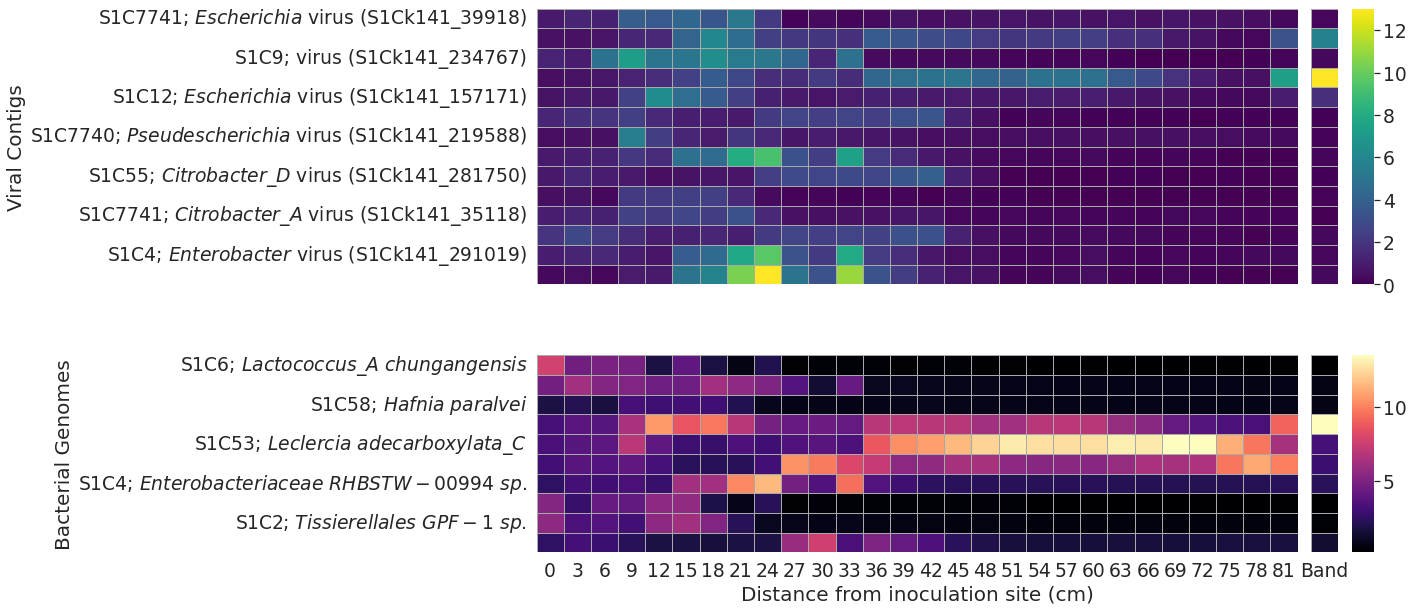

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set(font_scale=1.7)

# Read the bacterial MAG data
bacteria_mag = pd.read_csv('../data/MAGs/MAG_abundance_residual.csv', index_col='label')

# Prepare viral data
viral_data = np.sqrt(koverage_matrix_phage)
viral_main = np.sqrt(koverage_matrix_phage.iloc[:, :-1])
viral_last = np.sqrt(koverage_matrix_phage.iloc[:, -1:])

# Prepare bacterial data
bacteria_data = np.sqrt(bacteria_mag)
bacteria_main = np.sqrt(bacteria_mag.iloc[:, :-1])
bacteria_last = np.sqrt(bacteria_mag.iloc[:, -1:])
bacteria_last.columns = [['Band']]

# Calculate height ratios based on number of rows
height_ratio = [viral_main.shape[0], bacteria_main.shape[0]]

# Create figure - increased colorbar width
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 3, height_ratios=height_ratio, 
                      width_ratios=[viral_main.shape[1], 1, 0.8],
                      hspace=0.3, wspace=0.05)

# Top row - Viral heatmaps
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax1 = fig.add_subplot(gs[0, 2])

# update the columns names 
viral_main.columns = [distance_dict.get(k) for k in viral_main.columns]  
bacteria_main.columns = [distance_dict.get(k) for k in bacteria_main.columns]  

sns.heatmap(viral_main, ax=ax1, cbar=False, 
            linewidths=0.5, linecolor='darkgrey',
            cmap='viridis', xticklabels=False)
sns.heatmap(viral_last, ax=ax2, cbar=True, yticklabels=False,
            linewidths=0.5, linecolor='darkgrey',
            cmap='viridis', xticklabels=False,
            cbar_ax=cax1)
ax2.set_ylabel('')
ax1.set_ylabel('Viral Contigs', fontsize=20)

# Bottom row - Bacterial heatmaps
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
cax2 = fig.add_subplot(gs[1, 2])

sns.heatmap(bacteria_main, ax=ax3, cbar=False, 
            linewidths=0.5, linecolor='darkgrey',
            cmap='magma')
sns.heatmap(bacteria_last, ax=ax4, cbar=True, yticklabels=False,
            linewidths=0.5, linecolor='darkgrey',
            cmap='magma',
            cbar_ax=cax2)

# Italicize text after semicolon for bacterial labels
bacteria_labels = ax3.get_yticklabels()
new_bacteria_labels = []
for label in bacteria_labels:
    text = label.get_text()
    if ';' in text:
        parts = text.split(';', 1)
        # Escape underscores and spaces in the italic part
        italic_part = parts[1].strip().replace('_', r'\_').replace(' ', r'\ ')
        new_bacteria_labels.append(f"{parts[0]}; $\it{{{italic_part}}}$")
    else:
        new_bacteria_labels.append(text)
ax3.set_yticklabels(new_bacteria_labels)

ax4.set_ylabel('')
ax3.set_ylabel('Bacterial Genomes', fontsize=20)
ax3.set_xlabel('Distance from inoculation site (cm)', fontsize=20)
ax4.set_xlabel('')
plt.savefig('../figures/bacteria_phage_MAGs.png', dpi=300, bbox_inches='tight')
plt.show()

## See if any of the phages were binned into any of the high quality MAGs 

# compare abundance patterns of key mags 

In [13]:
# read in the taxonomy 
gtdb = pd.read_csv('../data/MAGs/gtdbtk.bac120.summary.tsv', sep = '\t')

# read in the checkm2 quality report
checkm2 = pd.read_csv('../data/MAGs/quality_report.tsv', sep = '\t')

checkm2_completeness70 = checkm2[checkm2['Completeness'] > 70]
checkm2_completeness70_contamination15 = checkm2_completeness70[checkm2_completeness70['Contamination'] < 15]


# rebuild the mag dataframe based on the ones that get dropped 
bin_files = glob.glob('/home/grig0076/scratch/TubePaper_2023/residual_community_data/vamb_cross_assembly/bins/*.fna')
bin_dict = {}
for b in bin_files: 
    b_dict = SeqIO.to_dict(SeqIO.parse(b, 'fasta'))
    b_keys = list(b_dict.keys()) 
    this_bin = re.split('\/',b)[-1][:-4]
    for bi in b_keys: 
        bin_dict[bi] = this_bin

# read in the coverage information
koverage = pd.read_csv('/home/grig0076/scratch/TubePaper_2023/residual_community_data/vamb_cross_assembly/koverage_2026/koverage.out/results/sample_coverage.tsv', sep = '\t')
koverage['bin'] = [bin_dict.get(b) for b in koverage['Contig']]
koverage['Contig_s'] = koverage['Contig']

# compute the coverage of contigs by reading in the contigs file with biopython and then using the names in the headers to create a dictionaSry 
contigs = dict(SeqIO.index('../data/MAGs/final.contigs.fa', "fasta"))
contig_keys = list(contigs.keys())
contig_length = [re.split('=', contigs.get(k).description)[-1]for k in contig_keys]
contig_length_dict = dict(zip(contig_keys, contig_length))

# update the coverage table with the information
koverage['length'] = pd.to_numeric([contig_length_dict.get(c[3:]) for c in koverage['Contig_s']])
#koverage['mean.length'] = pd.to_numeric(koverage['length']).multiply(pd.to_numeric(koverage['Mean']))
koverage['mean.length'] = pd.to_numeric(koverage['length']).multiply(pd.to_numeric(koverage['RPKM'])) # changing this to the RPKM 

# drop the contigs that are viral and will be analysed further
koverage = koverage[~koverage['Contig'].isin(['S1Ck141_145228', 'S1Ck141_192450'])]

bin_meancoverage = koverage.groupby(['Sample','bin'])['mean.length'].sum().reset_index()
bin_length = koverage[['Contig_s', 'bin', 'length']].drop_duplicates().groupby(['bin'])['length'].sum().reset_index()
bin_length_dict = dict(zip(bin_length['bin'], bin_length['length']))
# add the new measure to the table 
bin_meancoverage['mean.length/bin_length'] = [bin_meancoverage.loc[index]['mean.length']/bin_length_dict.get(s) for index, s in enumerate(bin_meancoverage['bin'])]

bin_meancoverage['bin'] = [b for b in bin_meancoverage['bin']]
bin_meancoverage_complete = bin_meancoverage[bin_meancoverage['bin'].isin(checkm2_completeness70_contamination15['Name'].to_list())]
gtdb_dict = dict(zip(gtdb['user_genome'], gtdb['classification']))
bin_meancoverage_complete['classification'] = [gtdb_dict.get(b) for b in bin_meancoverage_complete['bin']]
bin_meancoverage_complete['Sample'] = [s[:-4] for s in bin_meancoverage_complete['Sample']] 
order_dict = dict(zip(metadata['FAME ID (leave blank)'], metadata['Order']))
bin_meancoverage_complete['order'] = [order_dict[s] for s in bin_meancoverage_complete['Sample']]
bin_meancoverage_complete = bin_meancoverage_complete.sort_values('order')

# loop to generate labels: 
labels = [] 

for index, s in enumerate(bin_meancoverage_complete['classification']): 
    
    species = re.split(';', s)[-1][3:]
    label = '' 
    
    if species == '': 
        genus = re.split(';', s)[-2][3:]
        
        if genus == '': 
            family = re.split(';', s)[-3][3:]
            
            if family == '': 
                label = 'unknown' 
            
            elif family == 'GPF-1':
                order = re.split(';', s)[-4][3:] 
                label = order + ' ' + family + ' sp.'
            
            else: 
                label = family + ' sp.'
        
        else: 
            label = genus + ' sp.'
    
    elif 'RHBSTW-00994' in species: 
        family = re.split(';', s)[-3][3:] 
        label = family + ' RHBSTW-00994 sp.' 
    else: 
        label = species 
    
    labels.append(bin_meancoverage_complete['bin'].iloc[index] + '; ' + label) 
    
bin_meancoverage_complete['label'] = labels

# just make this heatmap in R using the pheatmap package 
df = bin_meancoverage_complete.pivot(index = 'label', columns = 'Sample', values = 'mean.length/bin_length')
df = df[metadata['FAME ID (leave blank)']]
df['species'] = [s for s in df.index]
df = df.sort_values('species', ascending=False).drop('species', axis=1)

<ipython-input-13-df522b696a8f>:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_meancoverage_complete['classification'] = [gtdb_dict.get(b) for b in bin_meancoverage_complete['bin']]
<ipython-input-13-df522b696a8f>:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_meancoverage_complete['Sample'] = [s[:-4] for s in bin_meancoverage_complete['Sample']]
<ipython-input-13-df522b696a8f>:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

In [14]:
koverage[koverage['Contig'] == 'S1Ck141_58790'].sort_values('Sample')

,Sample,Contig,Count,RPM,RPKM,RPK,TPM,Mean,Median,Hitrate,Variance,bin,Contig_s,length,mean.length
276915,FAME000104_S65,S1Ck141_58790,62,12.5600,2.52300,12.4600,10.7200,1.26500,0.0,0.42860,5.8660,S1C58,S1Ck141_58790,4977,12556.97100
190530,FAME000105_S56,S1Ck141_58790,11,1.9800,0.39780,2.2100,3.4330,0.22450,0.0,0.10200,0.5111,S1C58,S1Ck141_58790,4977,1979.85060
346023,FAME000106_S55,S1Ck141_58790,11,1.5680,0.31500,2.2100,2.8520,0.22450,0.0,0.08163,0.6777,S1C58,S1Ck141_58790,4977,1567.75500
207807,FAME000107_S54,S1Ck141_58790,62,8.1870,1.64500,12.4600,16.0300,1.26500,0.0,0.14290,19.8700,S1C58,S1Ck141_58790,4977,8187.16500
173253,FAME000108_S53,S1Ck141_58790,13,2.0700,0.41590,2.6120,3.0540,0.26530,0.0,0.14290,0.6156,S1C58,S1Ck141_58790,4977,2069.93430
155976,FAME000109_S52,S1Ck141_58790,7,1.1120,0.22350,1.4060,1.5410,0.14290,0.0,0.08163,0.2500,S1C58,S1Ck141_58790,4977,1112.35950
86868,FAME000110_S51,S1Ck141_58790,9,1.4460,0.29060,1.8080,1.9660,0.18370,0.0,0.18370,0.1531,S1C58,S1Ck141_58790,4977,1446.31620
363300,FAME000111_S50,S1Ck141_58790,17,1.8170,0.36500,3.4160,2.4420,0.34690,0.0,0.14290,1.5230,S1C58,S1Ck141_58790,4977,1816.60500
397854,FAME000112_S49,S1Ck141_58790,16,1.6320,0.32790,3.2150,2.2290,0.32650,0.0,0.16330,0.9745,S1C58,S1Ck141_58790,4977,1631.95830
259638,FAME000113_S48,S1Ck141_58790,6,0.4812,0.09669,1.2060,0.6580,0.12240,0.0,0.08163,0.1930,S1C58,S1Ck141_58790,4977,481.22613


In [19]:
viral_data.index

Index(['S1C7741; $\it{Escherichia}$ virus (S1Ck141_39918)',
       'S1C15; $\it{Citrobacter}$ virus (S1Ck141_40354)',
       'S1C9; virus (S1Ck141_234767)',
       'S1C56; $\it{Citrobacter}$ virus (S1Ck141_1791)',
       'S1C12; $\it{Escherichia}$ virus (S1Ck141_157171)',
       'S1C33; virus (S1Ck141_44171)',
       'S1C7740; $\it{Pseudescherichia}$ virus (S1Ck141_219588)',
       'S1C4; virus (S1Ck141_142512)',
       'S1C55; $\it{Citrobacter\_D}$ virus (S1Ck141_281750)',
       'S1C58; $\it{Hafnia}$ virus (S1Ck141_145228)',
       'S1C7741; $\it{Citrobacter\_A}$ virus (S1Ck141_35118)',
       'S1C55; $\it{Scandinavium}$ virus (S1Ck141_213095)',
       'S1C4; $\it{Enterobacter}$ virus (S1Ck141_291019)',
       'S1C4; virus (S1Ck141_192450)'],
      dtype='object')

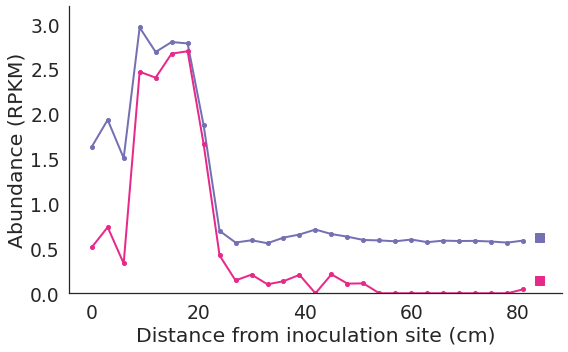

In [21]:
#set the style 
sns.set_style('white')

# Align column names
bacteria_data.columns = viral_data.columns

# Extract the data series, excluding the 'Band' column
bacteria_series = bacteria_data.loc['S1C58; Hafnia paralvei'].drop('Band')
viral_series = viral_data.loc['S1C58; $\it{Hafnia}$ virus (S1Ck141_145228)'].drop('Band')

# Extract the Band values separately
bacteria_band = bacteria_data.loc['S1C58; Hafnia paralvei', 'Band']
viral_band = viral_data.loc['S1C58; $\it{Hafnia}$ virus (S1Ck141_145228)', 'Band']

# Create figure - we only need one axis (ax1) now
fig, ax1 = plt.subplots(figsize=(8, 5))

color1 = '#7570b3' # Purple-ish
color2 = '#e7298a' # Pink-ish

# Plot Bacteria
ax1.plot(bacteria_series.index, bacteria_series.values, color=color1, 
         label='Hafnia paralvei (MAG S1C58)', marker='o', markersize=4, linewidth=2)
ax1.plot(84, bacteria_band, color=color1, marker='s', markersize=9, linestyle='none')

# Plot Phage on the SAME axis
ax1.plot(viral_series.index, viral_series.values, color=color2, 
         label='Hafnia Phage (Contig S1Ck141_145228)', marker='o', markersize=4, linewidth=2)
ax1.plot(84, viral_band, color=color2, marker='s', markersize=9, linestyle='none')

# Formatting
ax1.set_xlabel('Distance from inoculation site (cm)')
ax1.set_ylabel('Abundance (RPKM)')
ax1.set_ylim(0, 3.2) # Adjusted slightly for head room
#ax1.legend(frameon=False)

# Clean up layout
sns.despine()
fig.tight_layout()

plt.savefig('../figures/Hafnia_Unified_Scale.png', dpi=300, bbox_inches='tight')
plt.show()

Compare by making a plot of all of the contigs in the MAG

Pearson correlation: r=0.984, p=0.0000
Spearman correlation: ρ=0.877, p=0.0000


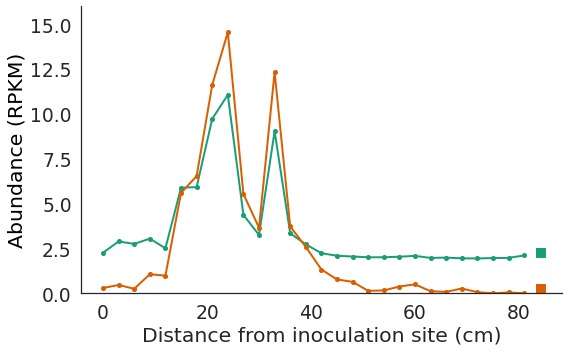

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Align column names
bacteria_data.columns = viral_data.columns

# Extract the data series, excluding the 'Band' column
bacteria_series = bacteria_data.loc['S1C4; Enterobacteriaceae RHBSTW-00994 sp.'].drop('Band')
viral_series = viral_data.loc['S1C4; virus (S1Ck141_192450)'].drop('Band')
#viral_series = viral_data.loc['S1Ck141_291019; Enterobacter'].drop('Band')
#viral_series = viral_data.loc['S1Ck141_306377'].drop('Band')

# Extract the Band values separately
bacteria_band = bacteria_data.loc['S1C4; Enterobacteriaceae RHBSTW-00994 sp.', 'Band']
viral_band = viral_data.loc['S1C4; virus (S1Ck141_192450)', 'Band']
#viral_band = viral_data.loc['S1Ck141_291019; Enterobacter', 'Band']
#viral_band = viral_data.loc['S1Ck141_306377', 'Band']

# Compute correlations (excluding Band values)
pearson_corr, pearson_p = pearsonr(bacteria_series.values, viral_series.values)
spearman_corr, spearman_p = spearmanr(bacteria_series.values, viral_series.values)

print(f"Pearson correlation: r={pearson_corr:.3f}, p={pearson_p:.4f}")
print(f"Spearman correlation: ρ={spearman_corr:.3f}, p={spearman_p:.4f}")

# Create figure and a single axis for shared scaling
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot bacteria data
color1 = '#1b9e77'
ax1.set_xlabel('Distance from inoculation site (cm)')
ax1.set_ylabel('Abundance (RPKM)', color='black') # Unified label

ax1.plot(bacteria_series.index, bacteria_series.values, color=color1, 
         label='Bacteria', marker='o', markersize=4, linewidth=2)
ax1.plot(84, bacteria_band, color=color1, marker='s', markersize=9, linestyle='none')

# --- UNIFIED SCALE SECTION ---
# Plot phage on the same ax1 instead of ax2
color2 = '#d95f02'
ax1.plot(viral_series.index, viral_series.values, color=color2, 
         label='Phage', marker='o', markersize=4, linewidth=2)
ax1.plot(84, viral_band, color=color2, marker='s', markersize=9, linestyle='none')

# Set a single limit that encompasses both datasets (0 to ~90)
ax1.set_ylim((0, 16)) 
# -----------------------------

# --- ORIGINAL TWINX BITS (Commented out for reference) ---
# ax2 = ax1.twinx()
# ax2.set_ylabel('Phage Abundance (RPKM)', color='black')
# ax2.tick_params(axis='y', labelcolor='black')
# ax2.set_ylim((0, 85))
# ---------------------------------------------------------

# Add legend to distinguish the two lines on the shared scale
#ax1.legend(loc='upper left', frameon=False)

# Aesthetics
sns.despine()
fig.tight_layout()

plt.savefig('../figures/abundance_RHBSTW-00994_shared.png', dpi=300, bbox_inches='tight')
plt.show()